In this notebook we explore more about eye tracking data analysis

In [11]:
# Derived from:
#     https://www.axonlab.org/hcph-sops/data-management/eyetrack-qc
# Load the autoreload extension
%load_ext autoreload
# Set autoreload to update the modules every time before executing a new line of code
%autoreload 2

%matplotlib inline
from pathlib import Path
import shutil
import json
import ppjson
from importlib import reload  # For debugging purposes

import numpy as np
import pandas as pd
import scipy.io as sio

import eyetrackingrun as et

from IPython.display import HTML
from matplotlib import animation
from matplotlib.animation import FuncAnimation, PillowWriter
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import copy
from write_bids_yiwei import EyeTrackingRun, write_bids, write_bids_from_df



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:

from ipyfilechooser import FileChooser
from IPython.display import display

fc = FileChooser("/Volumes/FS_PROJETS/MatTechLab/yiwei.jia/datasets/")
fc.title = "Select file or folder"
fc.show_only_dirs = False   # True = folders only
fc.filter_pattern = ["*.tsv.gz"]   # ← restrict file type

display(fc)

VerboseFlag= 0

FileChooser(path='/Volumes/FS_PROJETS/MatTechLab/yiwei.jia/datasets', filename='', title='Select file or folde…

In [24]:
import re

selected_path = Path(fc.selected)
print("Selected:", selected_path)
RECON_FOLDER_DATE = selected_path.parent.name
tsv_name = selected_path.name
if tsv_name.endswith(".tsv.gz"):
    FILE_NAME = tsv_name[:-len(".tsv.gz")]
else:
    raise ValueError("Unexpected file extension")
# -------- subject_idx (MIDxxxxx) --------
match = re.match(r"(MID\d+)_", FILE_NAME)
if not match:
    raise ValueError("Could not extract subject_idx from filename")

subject_idx = match.group(1)







# -------- results --------
print("subject_idx       =", subject_idx)
print("RECON_FOLDER_DATE =", RECON_FOLDER_DATE)
print("FILE_NAME         =", FILE_NAME)
print("tsv_name          =", tsv_name)
print("T_idx             =", T_idx)

# -------- T_idx (T1 / T2) --------
m = re.search(r'(^|[_\-.])T([12])(?:weighted)?(?=[_\-.]|$)', FILE_NAME, flags=re.IGNORECASE)
if not m:
    raise ValueError(f"Could not extract T_idx from filename: {FILE_NAME}")

T_idx = int(m.group(2))
print("T_idx =", T_idx)

Selected: /Volumes/FS_PROJETS/MatTechLab/yiwei.jia/datasets/26021801/MID00137_fixation_dots_T2weighted_2026-02-18_16h00.23.895.tsv.gz
subject_idx       = MID00137
RECON_FOLDER_DATE = 26021801
FILE_NAME         = MID00137_fixation_dots_T2weighted_2026-02-18_16h00.23.895
tsv_name          = MID00137_fixation_dots_T2weighted_2026-02-18_16h00.23.895.tsv.gz
T_idx             = 2
T_idx = 2


In [26]:

if T_idx == 1:
    mode = 'T1'
else:
    mode = 'T2'
    
BIDS_PATH = selected_path.parent

recording_file_src = BIDS_PATH / tsv_name
print(f'recording_file: {recording_file_src}')
metadata_file_src = recording_file_src.parent/ recording_file_src.name.replace(".tsv.gz", ".json")
print(f'metadata_file: {metadata_file_src}')



recording_file: /Volumes/FS_PROJETS/MatTechLab/yiwei.jia/datasets/26021801/MID00137_fixation_dots_T2weighted_2026-02-18_16h00.23.895.tsv.gz
metadata_file: /Volumes/FS_PROJETS/MatTechLab/yiwei.jia/datasets/26021801/MID00137_fixation_dots_T2weighted_2026-02-18_16h00.23.895.json


In [27]:
# Destination base folder
dest_dir = Path("/Users/cag/Documents/Dataset/recon_results/" + RECON_FOLDER_DATE)

# Create destination directory if needed
dest_dir.mkdir(parents=True, exist_ok=True)
for src in (recording_file_src, metadata_file_src):
    if not src.exists():
        raise FileNotFoundError(f"Source file not found: {src}")

    dst = dest_dir / src.name
    shutil.copy2(src, dst)   # copy2 preserves metadata

    print(f"Copied: {src} → {dst}")

recording_file = dest_dir / recording_file_src.name
metadata_file  = dest_dir / metadata_file_src.name

print("New recording_file:", recording_file)
print("New metadata_file :", metadata_file)

Copied: /Volumes/FS_PROJETS/MatTechLab/yiwei.jia/datasets/26021801/MID00137_fixation_dots_T2weighted_2026-02-18_16h00.23.895.tsv.gz → /Users/cag/Documents/Dataset/recon_results/26021801/MID00137_fixation_dots_T2weighted_2026-02-18_16h00.23.895.tsv.gz
Copied: /Volumes/FS_PROJETS/MatTechLab/yiwei.jia/datasets/26021801/MID00137_fixation_dots_T2weighted_2026-02-18_16h00.23.895.json → /Users/cag/Documents/Dataset/recon_results/26021801/MID00137_fixation_dots_T2weighted_2026-02-18_16h00.23.895.json
New recording_file: /Users/cag/Documents/Dataset/recon_results/26021801/MID00137_fixation_dots_T2weighted_2026-02-18_16h00.23.895.tsv.gz
New metadata_file : /Users/cag/Documents/Dataset/recon_results/26021801/MID00137_fixation_dots_T2weighted_2026-02-18_16h00.23.895.json


In [28]:

recording = pd.read_csv(
    recording_file,
#     sep=r"\s+",
    sep="\t",
    na_values="n/a",
)
recording.head()
print(f'recording len: {len(recording)}')
metadata = json.loads(metadata_file.read_text())
# print(f'meta_data: {metadata}')

print('The information from matlab:')
if T_idx == 1:
    twix_duration = 371817 #371817
    print(f'here the duration of the rawdata is: {twix_duration} ms with data points:46420')
else:
    twix_duration = 646617.5 #371817
    print(f'here the duration of the rawdata is: {twix_duration} ms with data points: 44000')




recording len: 952200
The information from matlab:
here the duration of the rawdata is: 646617.5 ms with data points: 44000


In [29]:
metadata

{'AverageCalibrationError': [0.65],
 'CalibrationCount': 1,
 'CalibrationLog': [[2255372,
   '>>>>>>> CALIBRATION (HV5,P-CR) FOR RIGHT: <<<<<<<<<'],
  [2255373, 'Calibration points:'],
  [2255373, '-40.8, -35.8         0,      0'],
  [2255373, '-41.3, -51.0         0,  -1726'],
  [2255373, '-41.8, -20.8         0,   1726'],
  [2255373, '-64.8, -36.1     -2439,      0'],
  [2255373, '-13.6, -37.7      2439,      0'],
  [2255373, 'eye check box: (L,R,T,B)\n\t  -70    -8   -54   -18'],
  [2255373, 'href cal range: (L,R,T,B)\n\t-3659  3659 -2588  2588'],
  [2255373,
   'Cal coeff:(X=a+bx+cy+dxx+eyy,Y=f+gx+goaly+ixx+jyy)\n  -4.5136e-07  96.058  1.5787 -0.2282  0.33416 \n  -3.3852e-07  2.9461  114.5  0.1872  0.058225'],
  [2255373, 'Prenormalize: offx, offy = -40.766 -35.816'],
  [2255373, 'Gains: cx:78.826 lx:90.832 rx:69.528'],
  [2255373, 'Gains: cy:121.482 ty:118.410 by:128.194'],
  [2255373, 'Resolution (upd) at screen center: X=3.3, Y=2.2'],
  [2255373, 'Gain Change Proportion: X: 0.30

# 1 Metadata and calibration

We always run a calibration before it is started. As a result, we will typically see the metadata corresponding to calibration on this particular run.

Now, let's print out the contents of the BIDS' sidecar JSON corresponding to the DWI in this session.

In [30]:
start_recording_message = 'RECCFG CR 1000 2 0 R'
start_recording_message_backup = 'ELCLCFG TOWER'
trigger_message = 'Key s trigger response'
target_timestamp = 0

for index, element in enumerate(metadata['LoggedMessages']):
    if (element[1] == start_recording_message) or (element[1] == start_recording_message_backup):
        print(f"ET start recording at index {index}: {element}")
        start_timestamp = element[0]
        print(f"at timestamp {start_timestamp}")
        break


for index, element in enumerate(metadata['LoggedMessages']):
    if element[1] == trigger_message:
        print(f"First Trigger occurrence is at index {index}: {element}")
        trigger_timestamp = element[0]
        print(f"at timestamp {trigger_timestamp}")
        break

# print(f"Timestamp to start recording: {metadata['StartTime']}")
# mri_duration = t1+7ms+tET
first_trigger_mr_start = 0 #yiwei flag
print(f'The first trigger (MRI start) -> MRI starts recordings:    {first_trigger_mr_start} ms')

gap_start_dot = start_timestamp - trigger_timestamp
print(f'From the trigger arrival to the start of ET recording: {gap_start_dot} ms')

ET start recording at index 3: [2290249, 'ELCLCFG TOWER']
at timestamp 2290249
First Trigger occurrence is at index 1: [2290243, 'Key s trigger response']
at timestamp 2290243
The first trigger (MRI start) -> MRI starts recordings:    0 ms
From the trigger arrival to the start of ET recording: 6 ms


In [31]:
metadata['LoggedMessages']

[[2270389, 'NO Reply is disabled for function eyelink_cal_result'],
 [2290243, 'Key s trigger response'],
 [2290243, 'Hello tracker record'],
 [2290249, 'ELCLCFG TOWER'],
 [2290745, 'Bye tracker record'],
 [2290747, 'T1w_LIBRE stimuli start'],
 [2290748, 'Stimuli after 0 seconds...'],
 [2390743, 'Stimuli after 100 seconds...'],
 [2490745, 'Stimuli after 200 seconds...'],
 [2590747, 'Stimuli after 300 seconds...'],
 [2690749, 'Stimuli after 400 seconds...'],
 [2790751, 'Stimuli after 500 seconds...'],
 [2890737, 'Stimuli after 600 seconds...'],
 [2990737, 'Stimuli after 700 seconds...'],
 [3090739, 'Stimuli after 800 seconds...'],
 [3190742, 'Stimuli after 900 seconds...']]

In [32]:
if VerboseFlag:
    print(recording[0:100])


In [33]:
t_axis = (
    recording.timestamp.values - recording.timestamp[0]
) / metadata["SamplingFrequency"]*1000
print(f"The end of the timestamp: {t_axis[-1]}")

The end of the timestamp: 952199.0


In [34]:
print(metadata["Columns"])
recording = recording.rename(
        columns={
            f"eye1_pupil_size": f"pupil_size",
            f"eye1_fixation": f"fixation",
            f"eye1_saccade": f"saccade",
            f"eye1_blink": f"blink",
            f"eye1_x_coordinate": f"x_coordinate", 
            f"eye1_y_coordinate": f"y_coordinate"         
        }
    )

metadata["Columns"] = recording.columns.tolist()
print(metadata["Columns"])

['eye1_x_coordinate', 'eye1_y_coordinate', 'eye1_pupil_size', 'eye1_pupil_x_coordinate', 'eye1_pupil_y_coordinate', 'eye1_href_x_coordinate', 'eye1_href_y_coordinate', 'eye1_x_velocity', 'eye1_href_x_velocity', 'eye1_raw_x_velocity', 'fast_raw_x_velocity', 'screen_ppdeg_x_coordinate', 'screen_ppdeg_y_coordinate', 'timestamp', 'eye1_fixation', 'eye1_saccade', 'eye1_blink']
['Unnamed: 0', 'x_coordinate', 'y_coordinate', 'pupil_size', 'eye1_pupil_x_coordinate', 'eye1_pupil_y_coordinate', 'eye1_href_x_coordinate', 'eye1_href_y_coordinate', 'eye1_x_velocity', 'eye1_href_x_velocity', 'eye1_raw_x_velocity', 'fast_raw_x_velocity', 'screen_ppdeg_x_coordinate', 'screen_ppdeg_y_coordinate', 'timestamp', 'fixation', 'saccade', 'blink']


In [35]:
recording.columns

Index(['Unnamed: 0', 'x_coordinate', 'y_coordinate', 'pupil_size',
       'eye1_pupil_x_coordinate', 'eye1_pupil_y_coordinate',
       'eye1_href_x_coordinate', 'eye1_href_y_coordinate', 'eye1_x_velocity',
       'eye1_href_x_velocity', 'eye1_raw_x_velocity', 'fast_raw_x_velocity',
       'screen_ppdeg_x_coordinate', 'screen_ppdeg_y_coordinate', 'timestamp',
       'fixation', 'saccade', 'blink'],
      dtype='object')

In [36]:
# See cleaned cell 4

In [37]:
plot_pupil_saccade = False

if plot_pupil_saccade:
    fig = plt.figure(figsize=(16, 2))

    plt.plot(
        t_axis,
        recording["pupil_size"].values,
    )

    plt.plot(
        t_axis,
        recording["saccade"].values * 5000,
    )

    plt.xlabel("time [s]")
    plt.ylabel("pupil area [a.u.]")
    plt.xlim((200, 220))
    plt.title('Pupil area and saccading')
    print(f'At this time, since blinking is detected, we cannot get clear pupil area ?')

In [38]:
plot_x_saccade = False
if plot_x_saccade:
    fig = plt.figure(figsize=(16, 2))
    plt.plot(
        t_axis,
        recording["x_coordinate"].values,
    )

    plt.plot(
        t_axis,
        recording["saccade"].values * 1000,
    )
    plt.xlim((200, 220))

Check fixation

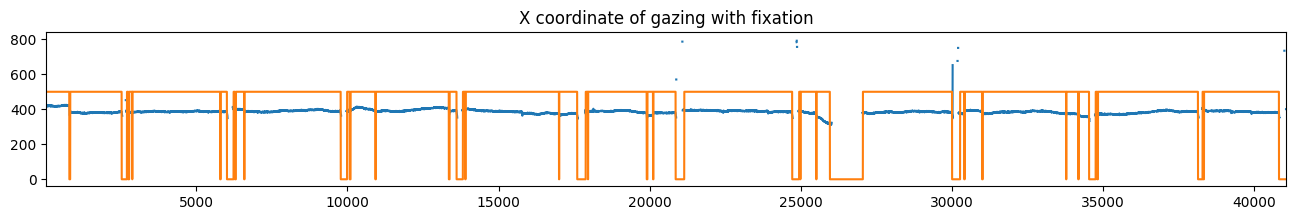

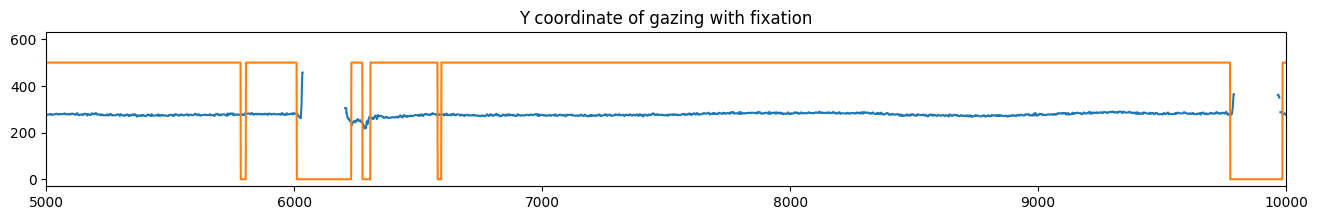

In [39]:
plot_fixation = True
if plot_fixation:
    # Fixation
    fig = plt.figure(figsize=(16, 2))
    plt.plot(
        t_axis,
        recording["x_coordinate"].values,
    )

    plt.plot(
        t_axis,
        recording["fixation"].values * 500,
    )
    plt.xlim((30, 41050))
    plt.title('X coordinate of gazing with fixation')

    fig = plt.figure(figsize=(16, 2))
    plt.plot(
        t_axis,
        recording["y_coordinate"].values,
    )

    plt.plot(
        t_axis,
        recording["fixation"].values * 500,
    )
    plt.xlim((5000, 10000))
    plt.title('Y coordinate of gazing with fixation')

The analysis did not reveal a strong correlation between pupil size and saccade or fixation events.

The coordinate sequence is stable during fixation, we should extract the data in the event.

# 2 Data Cleaning

- Seperate the two phases of sequences
- Extract the X Y coordinates
- Eliminate the blinking and non-fixation area of LIBRE data, and keep the raw data of STANDARD.Because there is no mechanism for the second STANDARD one to correct the eye fixation.
- Design some criteria for cleaning the noise data
    - Visual angle
    - Heat maps
    - Fixation algorithm (literature review)

## 2.1 Seperate the two phases of sequences

In [40]:
# -----------------------------
reset_index_bool = False
eliminate_all_nan = False
eliminate_first_nan = False
# -----------------------------

size = (
    metadata["ScreenAOIDefinition"][1][1],
    metadata["ScreenAOIDefinition"][1][3],
)

coor_data = recording[["x_coordinate", "y_coordinate"]]
print(f"Extract X Y coordinates from recording: {len(coor_data)}")

if eliminate_all_nan:
    coor_data = coor_data[coor_data.x_coordinate.notna() & coor_data.y_coordinate.notna()]
    coor_recording = recording[recording.x_coordinate.notna() & recording.y_coordinate.notna()]
elif eliminate_first_nan:
    # Find the first non-NaN row
    first_valid_index = coor_data[['x_coordinate', 'y_coordinate']].dropna(how='all').index[0]

    # Slice the DataFrame from the first non-NaN row onward
    coor_data = coor_data.iloc[first_valid_index:]
    
    coor_recording = recording.iloc[first_valid_index:]
    
else:
    coor_recording = recording

if reset_index_bool:
    coor_data.reset_index(drop=True, inplace=True)
    coor_recording.reset_index(drop=True, inplace=True)
    
print(coor_data)
print(f"Eliminating nan values? {eliminate_first_nan}: {len(coor_data)}")
print(f'len of coor_data {len(coor_data)} should be equal to len of coor_recording {len(coor_recording)}')

Extract X Y coordinates from recording: 952200
        x_coordinate  y_coordinate
0         377.500000    265.700012
1         377.200012    266.000000
2         376.399994    266.200012
3         374.899994    266.100006
4         374.200012    266.700012
...              ...           ...
952195    396.799988    262.100006
952196    396.500000    262.899994
952197    396.399994    263.700012
952198    396.200012    263.100006
952199    395.899994    261.799988

[952200 rows x 2 columns]
Eliminating nan values? False: 952200
len of coor_data 952200 should be equal to len of coor_recording 952200


In [43]:
# Duration setting according to the protocol (in sec) not any more
# Duration setting according to the raw data info

# offset from start of recording to the stimulation...
offset = np.int16(np.round(first_trigger_mr_start + gap_start_dot))
if T_idx == 1:
    T1_LIBRE = (twix_duration - offset)/metadata['SamplingFrequency']
        
    T1_GAP = 0
    T1_BASE = len(recording) - twix_duration
else:
    T2_LIBRE = (twix_duration - offset)/metadata['SamplingFrequency']
        
    T2_GAP = 0
    T2_BASE = len(recording) - twix_duration


print(f"The length of ET recording we need for {mode} LIBRE {subject_idx} should be: {T1_LIBRE} sec")


The length of ET recording we need for T2 LIBRE MID00137 should be: 646.6115 sec


mode: T2
set start margin as 0
646612


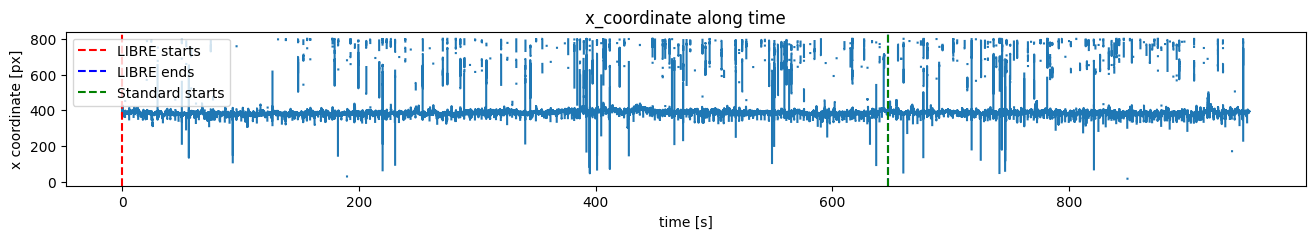

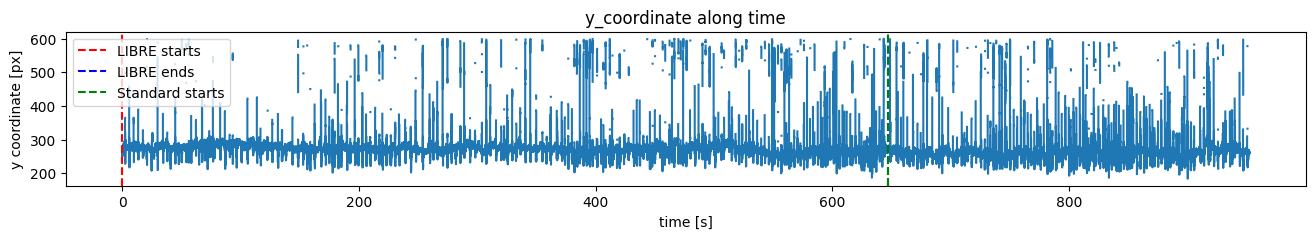

In [45]:
start_margin = 0
if mode == 'T1':
    print(f'mode: {mode}')
    print(f"set start margin as {start_margin}")
    T1_LIBRE_sample = np.ceil(T1_LIBRE*metadata['SamplingFrequency'])
    # we don't care
    T1_GAP_sample = T1_GAP*metadata['SamplingFrequency']
    # we don't care
   
else:
    print(f'mode: {mode}')
    print(f"set start margin as {start_margin}")
    T2_LIBRE_sample = np.ceil(T2_LIBRE*metadata['SamplingFrequency'])
    T2_GAP_sample = T2_GAP*metadata['SamplingFrequency']

    


t_axis_xy = (
    coor_data.index 
) / metadata["SamplingFrequency"]

# x coordinate
fig = plt.figure(figsize=(16, 2))

plt.plot(
    t_axis_xy,
    coor_data["x_coordinate"].values,
)

if mode == 'T1':
    plt.axvline(x=start_margin/metadata["SamplingFrequency"], color='r', linestyle='--', label='LIBRE starts')
    plt.axvline(x=(T1_LIBRE_sample+start_margin)/metadata["SamplingFrequency"], color='b', linestyle='--', label='LIBRE ends')
    plt.axvline(x=(T1_LIBRE_sample+start_margin+T1_GAP_sample)/metadata["SamplingFrequency"], color='g', 
                linestyle='--', label='Standard starts')
else:
    plt.axvline(x=start_margin/metadata["SamplingFrequency"], color='r', linestyle='--', label='LIBRE starts')
    plt.axvline(x=(T2_LIBRE_sample+start_margin)/metadata["SamplingFrequency"], color='b', linestyle='--', label='LIBRE ends')
    plt.axvline(x=(T2_LIBRE_sample+start_margin+T2_GAP_sample)/metadata["SamplingFrequency"], color='g', 
                linestyle='--', label='Standard starts')

if mode == 'T1':
    plt.title("x_coordinate along time")
    plt.xlabel("time [s]")
    plt.ylabel("x coordinate [px]")
    plt.legend()
    
    # y coordinate
    fig = plt.figure(figsize=(16, 2))
    
    plt.plot(
        t_axis_xy,
        coor_data["y_coordinate"].values,
    )
    
    plt.axvline(x=start_margin/metadata["SamplingFrequency"], color='r', linestyle='--', label='LIBRE starts')
    plt.axvline(x=(T1_LIBRE_sample+start_margin)/ metadata["SamplingFrequency"], color='b', linestyle='--', label='LIBRE ends')
    plt.axvline(x=(T1_LIBRE_sample+start_margin+T1_GAP_sample)/metadata["SamplingFrequency"], color='g', 
                linestyle='--', label='Standard starts')
    
        
    plt.title("y_coordinate along time")
    plt.xlabel("time [s]")
    plt.ylabel("y coordinate [px]")
    plt.legend()
    
    
    coor_data_LIBRE = coor_data[start_margin:int(T1_LIBRE_sample)+start_margin] 
    coor_recording_LIBRE = coor_recording[start_margin:int(T1_LIBRE_sample)+start_margin] 
    coor_data_LIBRE_raw = copy.deepcopy(coor_data_LIBRE)
    print(len(coor_data_LIBRE))
    
else:
    plt.title("x_coordinate along time")
    plt.xlabel("time [s]")
    plt.ylabel("x coordinate [px]")
    plt.legend()
    
    # y coordinate
    fig = plt.figure(figsize=(16, 2))
    
    plt.plot(
        t_axis_xy,
        coor_data["y_coordinate"].values,
    )
    
    plt.axvline(x=start_margin/metadata["SamplingFrequency"], color='r', linestyle='--', label='LIBRE starts')
    plt.axvline(x=(T2_LIBRE_sample+start_margin)/ metadata["SamplingFrequency"], color='b', linestyle='--', label='LIBRE ends')
    plt.axvline(x=(T2_LIBRE_sample+start_margin+T2_GAP_sample)/metadata["SamplingFrequency"], color='g', 
                linestyle='--', label='Standard starts')
    
        
    plt.title("y_coordinate along time")
    plt.xlabel("time [s]")
    plt.ylabel("y coordinate [px]")
    plt.legend()
    
    
    coor_data_LIBRE = coor_data[start_margin:int(T2_LIBRE_sample)+start_margin] 
    coor_recording_LIBRE = coor_recording[start_margin:int(T2_LIBRE_sample)+start_margin] 
    coor_data_LIBRE_raw = copy.deepcopy(coor_data_LIBRE)
    print(len(coor_data_LIBRE))    


In [46]:
# import scipy.io
# coor_array = coor_data_LIBRE[['x_coordinate', 'y_coordinate']].to_numpy()
# scipy.io.savemat(f'coor_data_raw_t1w_libre_sub00{subject_idx}.mat', {'coordinates': coor_array})

## 2.2 Eliminating blinking

In [47]:
use_eliminate_blink = True

def eliminate_blink(coor_data, coor_recording, seq_name):
#     coor_data = coor_data[coor_recording.blink < 1]
#     coor_recording = coor_recording[coor_recording.blink < 1]
# Note: instead of filtering them out, I assign nan to the invalid elements
    print(f'The data will be eliminated: {len(coor_data[coor_recording.blink > 0])}')
    coor_data.loc[coor_recording.blink > 0,  ['x_coordinate', 'y_coordinate']] = np.nan
    coor_recording.loc[coor_recording.blink > 0,  ['x_coordinate', 'y_coordinate']] = np.nan
    print(f'After eliminating blinking: \nlen of coor_data_{seq_name} {len(coor_data)} \
      should be equal to len of coor_recording {len(coor_recording)}')
    return coor_data, coor_recording


if use_eliminate_blink:
    coor_data_LIBRE,  coor_recording_LIBRE = eliminate_blink(coor_data_LIBRE, coor_recording_LIBRE, 'LIBRE')
# coor_data_STANDARD,  coor_recording_STANDARD = eliminate_blink(coor_data_STANDARD, 
#                                                                coor_recording_STANDARD, 'STANDARD')
plot_heatmap = False
if plot_heatmap:
    import plot
    plot.plot_heatmap_coordinate(coor_data_LIBRE, density=False, screen_size=size, 
                                 title='LIBRE: The gaze from the beginning to the end')
    plot.plot_heatmap_coordinate(coor_data_STANDARD, density=False, screen_size=size, 
                                 title='STANDARD: The gaze from the beginning to the end')

The data will be eliminated: 58182
After eliminating blinking: 
len of coor_data_LIBRE 646612       should be equal to len of coor_recording 646612


/var/folders/x4/yl1kbpks5sxc3345y3ttk6gm0000gn/T/ipykernel_19357/395681592.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coor_data.loc[coor_recording.blink > 0,  ['x_coordinate', 'y_coordinate']] = np.nan


In [48]:
# coor_data_LIBRE[coor_recording_LIBRE.blink > 0]

## 2.3 Preserving fixation

In [49]:
use_preserve_fixation = True

def preserve_fixation(coor_data, coor_recording, seq_name):
#     coor_data = coor_data[coor_recording.fixation > 0]
#     coor_recording = coor_recording[coor_recording.fixation > 0]
    print(f'The data will be eliminated: {len(coor_data[coor_recording.fixation < 1])}')
    coor_data.loc[coor_recording.fixation < 1, ['x_coordinate', 'y_coordinate']] = np.nan
    coor_recording.loc[coor_recording.fixation < 1, ['x_coordinate', 'y_coordinate']] = np.nan

    print(f'After preserving fixation: \nlen of coor_data_{seq_name} {len(coor_data)} \
      should be equal to len of coor_recording {len(coor_recording)}')
    return coor_data, coor_recording


if use_preserve_fixation:
    coor_data_LIBRE,  coor_recording_LIBRE = preserve_fixation(coor_data_LIBRE, coor_recording_LIBRE, 'LIBRE')
    # coor_data_STANDARD,  coor_recording_STANDARD = preserve_fixation(coor_data_STANDARD, 
    #                                                                coor_recording_STANDARD, 'STANDARD')
plot_heatmap = False
if plot_heatmap:
    import plot
    plot.plot_heatmap_coordinate(coor_data_LIBRE, density=False, screen_size=size, 
                                 title='LIBRE: The gaze from the beginning to the end')
    plot.plot_heatmap_coordinate(coor_data_STANDARD, density=False, screen_size=size, 
                                 title='STANDARD: The gaze from the beginning to the end')

The data will be eliminated: 69157
After preserving fixation: 
len of coor_data_LIBRE 646612       should be equal to len of coor_recording 646612


/var/folders/x4/yl1kbpks5sxc3345y3ttk6gm0000gn/T/ipykernel_19357/1236913166.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coor_data.loc[coor_recording.fixation < 1, ['x_coordinate', 'y_coordinate']] = np.nan


## 2.4 Plot the gazing dots

In [50]:
# see cleaned_cell [1]

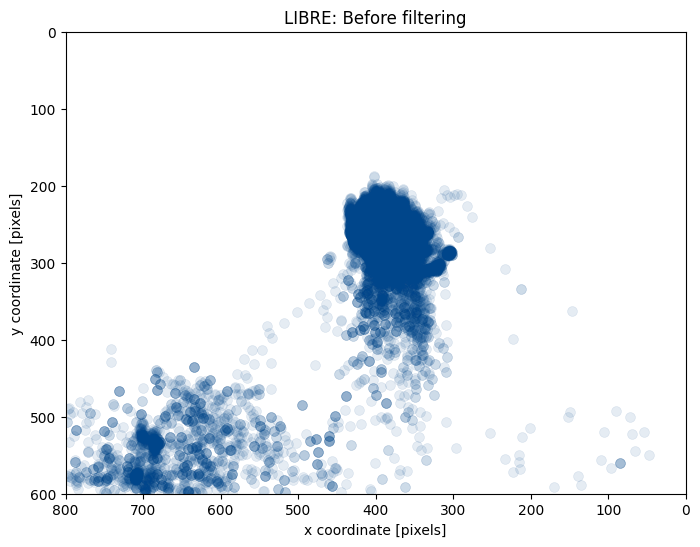

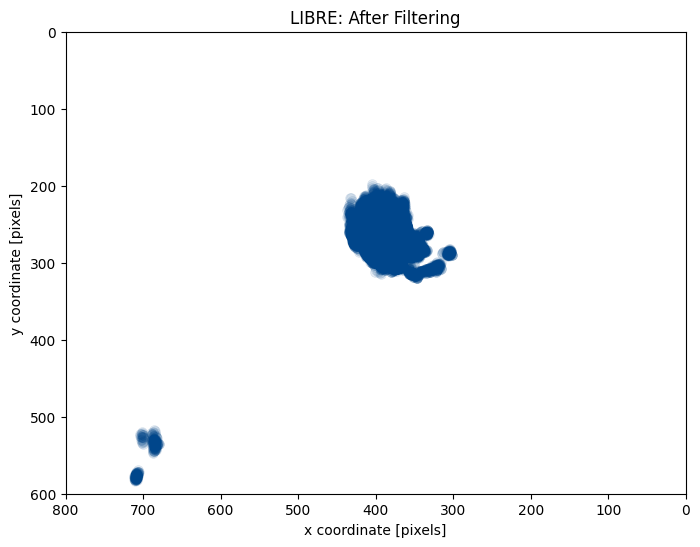

In [51]:
# Example data (replace with your actual data)
X_coord = coor_data_LIBRE_raw['x_coordinate']
Y_coord = coor_data_LIBRE_raw['y_coordinate']
fig, ax= plt.subplots(figsize=(8, 6))
# Plot the data, flipping X coordinates and using dots as markers
plt.scatter(X_coord, Y_coord, s=50, c='#00468b', alpha=0.1, edgecolors='#00468b', linewidth=0.5)
plt.xlim((0, 800))
plt.ylim((0, 600))
# Set plot title
plt.title('LIBRE: Before filtering')
plt.xlabel('x coordinate [pixels]')
plt.ylabel('y coordinate [pixels]')
# Reverse the direction of the Y-axis
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

# ============================================================
# Example data (replace with your actual data)
X_coord = coor_data_LIBRE['x_coordinate']
Y_coord = coor_data_LIBRE['y_coordinate']
fig, ax= plt.subplots(figsize=(8, 6))
# Plot the data, flipping X coordinates and using dots as markers
plt.scatter(X_coord, Y_coord, s=50, c='#00468b', alpha=0.1, edgecolors='#00468b', linewidth=0.5)
plt.xlim((0, 800))
plt.ylim((0, 600))
# Set plot title
plt.title('LIBRE: After Filtering')
plt.xlabel('x coordinate [pixels]')
plt.ylabel('y coordinate [pixels]')
# Reverse the direction of the Y-axis
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
# ============================================================



By far, we initially cleaned data based on the inherent properties in the metadata from EyeLink. And we plotted the fixation evaluation. 

In [52]:
# see cleaned_cell [2]

## 2.5 Visualize gaze groups

In [53]:
def cal_diff_distance(x_coord, y_coord):
    
    # Calculate differences
    # * 81.3 / 176
    # * 62 / 137
    dx = np.diff(x_coord)  # Difference in x
    dy = np.diff(y_coord)   # Difference in y
    
    # Check for NaN values, ravel() is the must
   
    nan_mask = (
    np.isnan(x_coord[:-1]).ravel() |
    np.isnan(x_coord[1:]).ravel()  |
    np.isnan(y_coord[:-1]).ravel() |
    np.isnan(y_coord[1:]).ravel()
    )
    
    # Calculate Euclidean distances
    distances = np.sqrt(dx**2 + dy**2)
    # Apply NaN mask

    distances[nan_mask] = np.nan

    
    return distances

def cal_diff_sum_window(x_coord, y_coord, window_size=7):
    # Calculate differences
    # * 81.3 / 176
    # * 62 / 137
    distances = cal_diff_distance(x_coord, y_coord)
    half_window = window_size // 2

    # Create an empty array to store the sum of each window
    window_sums = []
    for i in range(len(x_coord)):
        # Get the start and end indices of the window
        start_idx = max(0, i - half_window)
        end_idx = min(len(distances), i + half_window + 1)
        
        # Slice the array and calculate the sum of the window
        window_sum = np.nansum(distances[start_idx:end_idx])
        
        # Append the window sum to the result list
        window_sums.append(window_sum)
    
    # Convert the list of sums to a numpy array for easier manipulation
    window_sums = np.array(window_sums)
    
    return window_sums


def calculate_max_pairwise_distance(x_coord, y_coord):
    """
    Calculate the maximum Euclidean distance between each pair of coordinates.

    Args:
    coords (numpy.ndarray): An array of shape (n, 2), where n is the number of coordinates, 
                            and each row contains (x, y) coordinates.

    Returns:
    float: The maximum distance between any pair of coordinates.
    """
    
    coords = np.column_stack((x_coord, y_coord))
    diffs = coords[:, np.newaxis, :] - coords[np.newaxis, :, :]  # Shape (n, n, 2)
    
    # Compute Euclidean distances for all pairs
    distances = np.sqrt(np.nansum(diffs**2, axis=-1))  # Shape (n, n)
    
    # Find the maximum distance
    max_distance = np.nanmax(distances)
    
    return max_distance
    
def cal_max_distance_window(x_coord, y_coord, window_size=7):
    from tqdm import tqdm
    half_window = window_size // 2

    # Create an empty array to store the sum of each window
    window_max_array = []
    for i in tqdm(range(len(x_coord)), desc="Processing"):
       
        # Get the start and end indices of the window
        start_idx = max(0, i - half_window)
        end_idx = min(len(x_coord), i + half_window + 1)
        
        # Slice the array and calculate the sum of the window
        window_max = calculate_max_pairwise_distance(x_coord[start_idx:end_idx], y_coord[start_idx:end_idx])
        
        # Append the window sum to the result list
        window_max_array.append(window_max)
    
    # Convert the list of sums to a numpy array for easier manipulation
    window_max_array = np.array(window_max_array)

    return window_max_array

(646611,)


Text(0, 0.5, 'distance (pixel)')

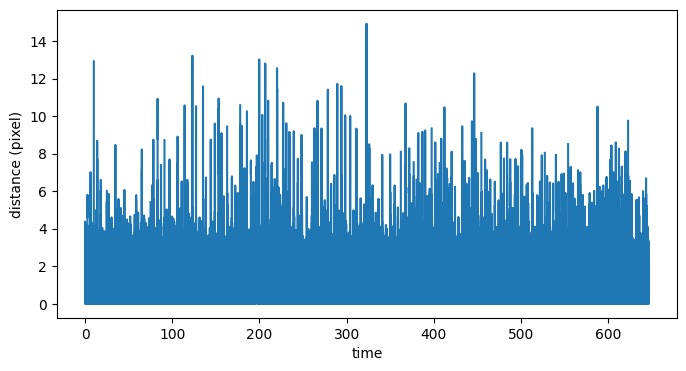

In [54]:
X_coord = coor_data_LIBRE['x_coordinate']
Y_coord = coor_data_LIBRE['y_coordinate']

t_axis_xy = (
    coor_data_LIBRE.index 
) / metadata["SamplingFrequency"]
distances = cal_diff_distance(X_coord, Y_coord)
print(distances.shape)

fig, ax= plt.subplots(figsize=(8, 4))
plt.plot(t_axis_xy[1:],
         distances)


plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=10)
plt.xlabel('time')
plt.ylabel('distance (pixel)')


(646612,)


Text(0, 0.5, 'distance (pixel)')

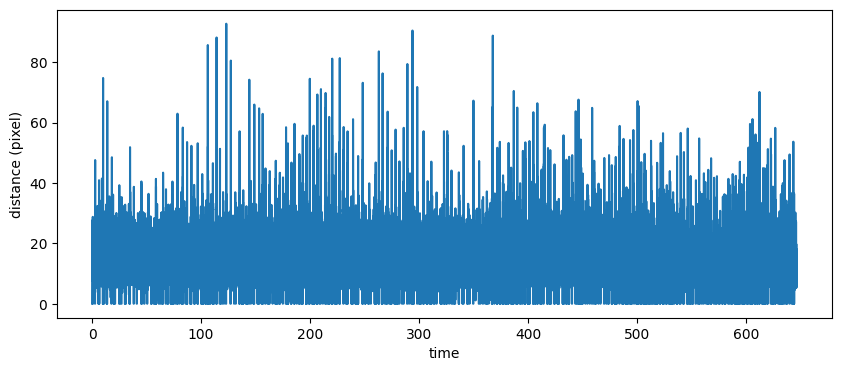

In [55]:
fig, ax= plt.subplots(figsize=(10, 4))
distances_win = cal_diff_sum_window(X_coord, Y_coord, window_size=7*2)
print(distances_win.shape)
plt.plot(t_axis_xy,
         distances_win)
plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=10)
plt.xlabel('time')
plt.ylabel('distance (pixel)')

In [56]:
# fig, ax= plt.subplots(figsize=(10, 4))
# window_size = 80
# distances_max_win = cal_max_distance_window(X_coord, Y_coord, window_size=window_size)
# print(distances_win.shape)
# plt.plot(t_axis_xy,
#          distances_max_win)
# plt.tick_params(axis='x', labelsize=10)
# plt.tick_params(axis='y', labelsize=10)
# plt.xlabel('time')
# plt.ylabel('distance (pixel)')


# save_mask_path = f'./masks_250127/subject_{subject_idx}_max_dist_win_{window_size}.mat'
# sio.savemat(save_mask_path, {'distances_max_win': distances_max_win})
# print(f'The mask file has been saved here: {save_mask_path}')
# print(len(distances_max_win[distances_max_win>60]))
# print(len(distances_max_win))

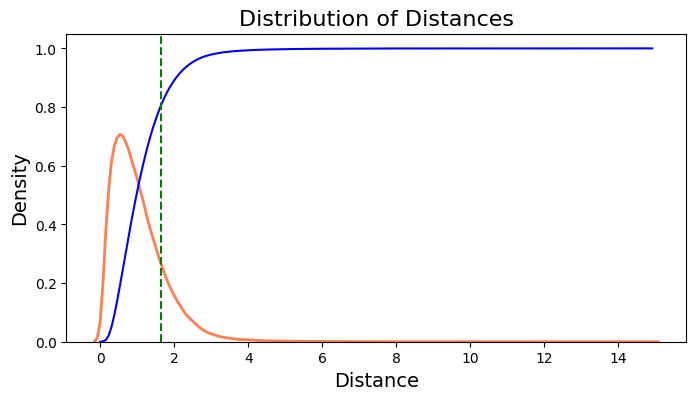

1.6500523886154714


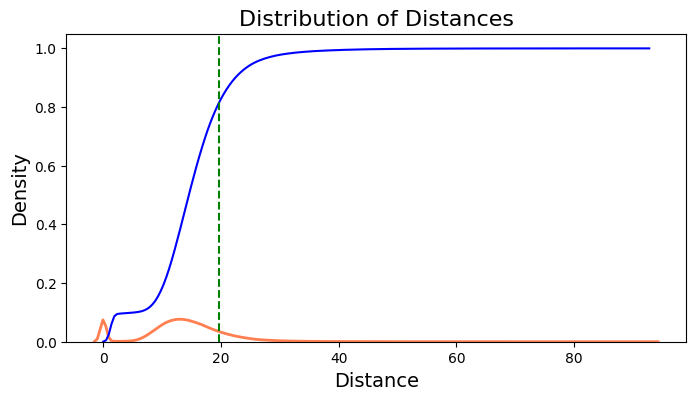

19.5818183077964


In [57]:
def plt_distribution(distances, threshold=0.8):
    import seaborn as sns

    # Filter out NaN values from the distances
    valid_distances = distances[~np.isnan(distances)]
    
    # Plot the distribution: KDE
    fig, ax= plt.subplots(figsize=(8, 4))

    kde_plot = sns.kdeplot(valid_distances, color='coral', linewidth=2, label='KDE Plot')
    # Get the x and y values from the plot (not the plot object itself)
    x_values = kde_plot.get_lines()[0].get_xdata()
    kde_values = kde_plot.get_lines()[0].get_ydata()
    # Add labels and legend
    ax.set_xlabel('Distance', fontsize=14)
    ax.set_ylabel('Density', fontsize=14)
    ax.set_title('Distribution of Distances', fontsize=16)


    # Plot the cdf values
   
    cdf_values = np.cumsum(kde_values)  # Cumulative sum
    # Normalize the CDF to range from 0 to 1
    cdf_values /= cdf_values[-1]
    x_values = np.linspace(min(valid_distances), max(valid_distances), len(cdf_values))  # Define x range
    ax.plot(x_values, cdf_values, label='CDF', color='blue')
    # Normalize the CDF to range from 0 to 1
    cdf_values /= cdf_values[-1]
    # Find the threshold value for 80% accumulation
    threshold_index = np.argmax(cdf_values >= threshold)
    threshold_value = x_values[threshold_index]
    
    ax.axvline(threshold_value, color='green', linestyle='--', label=f'80% Threshold: {threshold_value:.2f}')


    # Show plot
    plt.show()
    return threshold_value

threshold_value = plt_distribution(distances, threshold=0.8)
print(threshold_value)

threshold_value = plt_distribution(distances_win, threshold=0.8)
print(threshold_value)

# threshold_value = plt_distribution(distances_max_win, threshold=0.9)
# print(threshold_value)

In [58]:
def cal_statistics(distances):
    mean_distance = np.nanmean(distances)
    std_distance = np.nanstd(distances)
    median_distance = np.nanmedian(distances)
    min_distance = np.nanmin(distances)
    max_distance = np.nanmax(distances)
    nan_count = np.sum(np.isnan(distances))  # Count NaN values
    
    # Display the results
    print(f"Mean distance: {mean_distance:.2f}")
    print(f"Standard deviation: {std_distance:.2f}")
    print(f"Median distance: {median_distance:.2f}")
    print(f"Minimum distance: {min_distance:.2f}")
    print(f"Maximum distance: {max_distance:.2f}")
    print(f"Number of NaN values: {nan_count}")
    
cal_statistics(distances)
cal_statistics(distances_win)
# cal_statistics(distances_max_win)

Mean distance: 1.04
Standard deviation: 0.76
Median distance: 0.89
Minimum distance: 0.00
Maximum distance: 14.93
Number of NaN values: 69816
Mean distance: 13.86
Standard deviation: 7.28
Median distance: 13.74
Minimum distance: 0.00
Maximum distance: 92.78
Number of NaN values: 0


## Generate movement distance mask

In [59]:
def generate_movement_mask(distances_max_win, offset, move_criteria):
    # Generate the mask
    # the threshold should be within voxel size, or some relationship with voxel size.
    distances_max_win = distances_max_win[:]
    
    move_discard_mask = (
        (distances_max_win > move_criteria) | np.isnan(distances_max_win)
        )
    move_preserve_mask = ~(move_discard_mask)
    
    
    # Check the result
    print("Mask shape:", move_preserve_mask.shape)
    print("After appending size of offset", offset)
    preffix_mask = np.zeros(offset)
    # Concatenate the two arrays
    move_preserve_mask = np.concatenate((preffix_mask, move_preserve_mask))
    print("Mask shape:", move_preserve_mask.shape)
    
    return move_preserve_mask


# offset_first_trigger_mriStart = first trigger interval (according to log.txt) - (first mri meas - first marker)


# move_criteria = 20
# offset = mri_start_first_trigger + gap_start_dot #t1+6ms
# move_preserve_mask = generate_movement_mask(distances_max_win, offset, move_criteria)

# save_move_preserve_mask = False
# if save_move_preserve_mask:
#     save_mask_path = f'./masks_250127/subject_{subject_idx}_move_win{window_size}_crit{move_criteria}_mask.mat'
#     sio.savemat(save_mask_path, {'move_preserve_mask': move_preserve_mask})
#     print(f'The mask file has been saved here: {save_mask_path}')

## Analyzing Gaze Point Distribution Before and After Filtering

After filtering out blink-related timestamps by assigning NaN to gaze coordinates, it's important to inspect how this operation has affected the distribution of gaze points along each dimension (e.g., x_coordinate and y_coordinate).

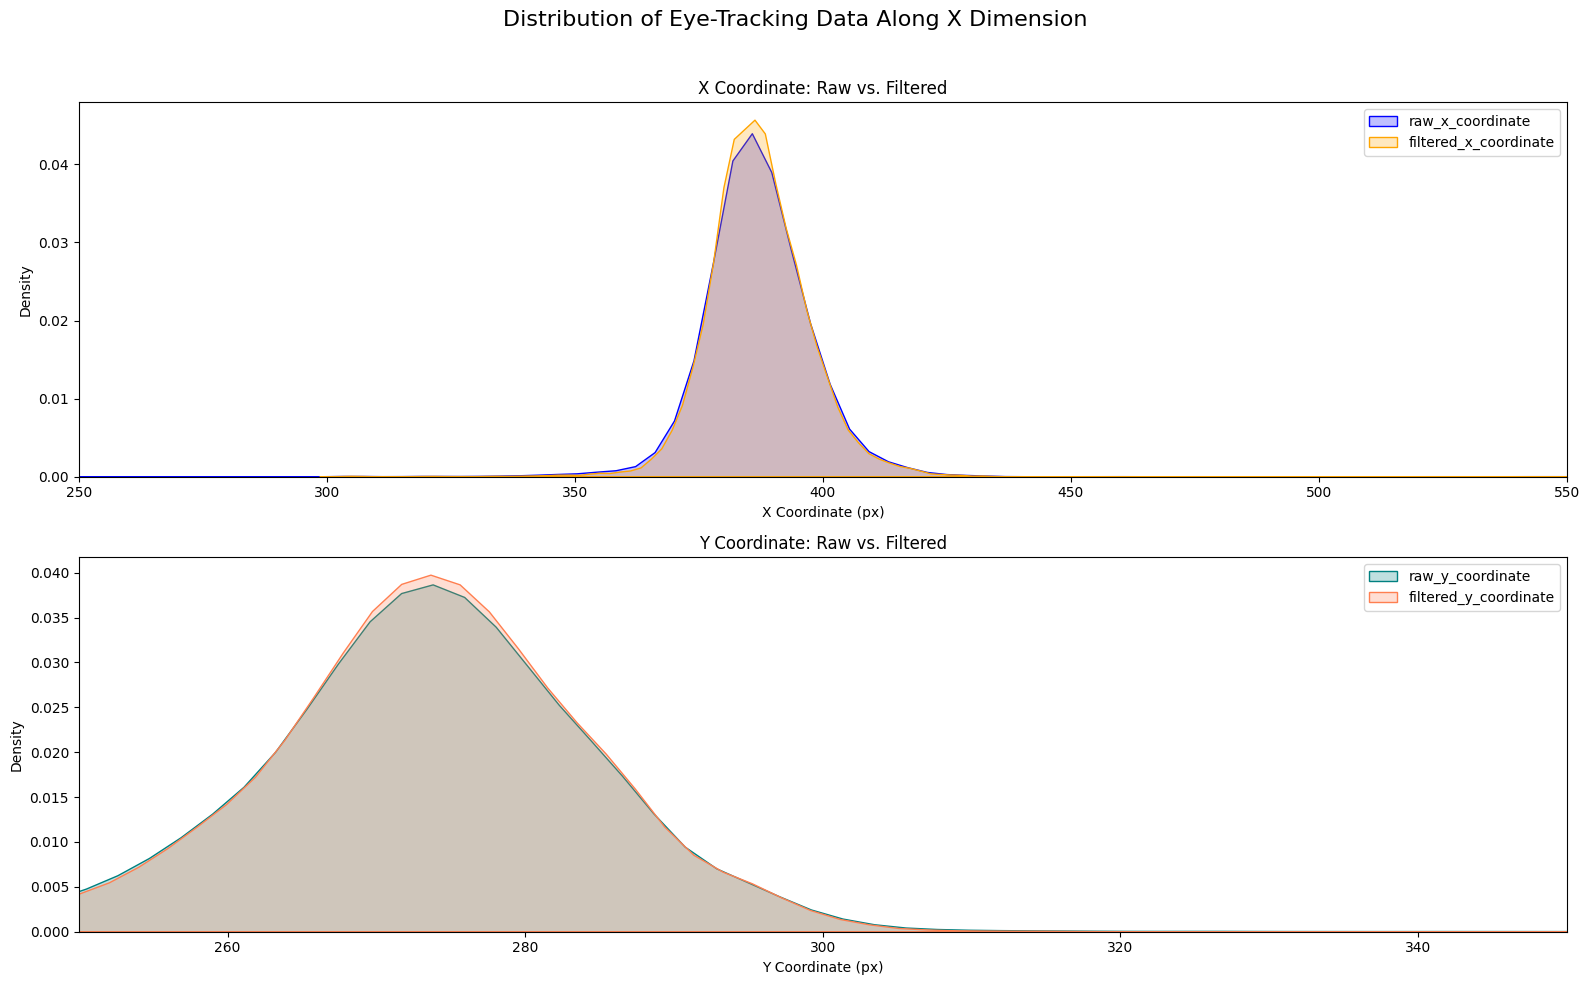

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the figure
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot KDE for eye1_x_coordinate
sns.kdeplot(coor_data_LIBRE_raw['x_coordinate'].dropna(), ax=axes[0], color='blue', fill=True, label='raw_x_coordinate')
sns.kdeplot(coor_data_LIBRE['x_coordinate'].dropna(), ax=axes[0], color='orange', fill=True, label='filtered_x_coordinate')
axes[0].set_title("X Coordinate: Raw vs. Filtered")
axes[0].set_xlabel("X Coordinate (px)")
axes[0].set_ylabel("Density")
axes[0].set_xlim((250,550))
axes[0].legend()

# Plot KDE for y coordinate
sns.kdeplot(coor_data_LIBRE_raw["y_coordinate"].dropna(), ax=axes[1], color='teal', fill=True, label='raw_y_coordinate')
sns.kdeplot(coor_data_LIBRE["y_coordinate"].dropna(), ax=axes[1], color='coral', fill=True, label='filtered_y_coordinate')
axes[1].set_title("Y Coordinate: Raw vs. Filtered")
axes[1].set_xlabel("Y Coordinate (px)")
axes[1].set_ylabel("Density")
axes[1].set_xlim((250,350))
axes[1].legend()

# Add a common title
fig.suptitle("Distribution of Eye-Tracking Data Along X Dimension", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [61]:
from mask_gen import cal_mask, plot_x_y_coord, filter_XY_coord

In [62]:
def cal_stats(coor_data):
    stats_dict = {}
    X_coord = coor_data["x_coordinate"].values
    Y_coord = coor_data["y_coordinate"].values
    
    stats_dict['x_mean'] = np.nanmean(X_coord)
    stats_dict['x_median'] = np.nanmedian(X_coord)      # Median, ignoring NaNs
    stats_dict['x_std'] = np.nanstd(X_coord)        # Standard deviation
    stats_dict['x_min'] = np.nanmin(X_coord)      # Minimum value
    stats_dict['x_max'] = np.nanmax(X_coord)      # Maximum value
    # Calculate 25th, 50th (median), and 75th percentiles while ignoring NaN values
    stats_dict['x_q25'] = np.nanpercentile(X_coord, 25)  # 25th percentile
    stats_dict['x_q75'] = np.nanpercentile(X_coord, 75)  # 75th percentile

    stats_dict['y_mean'] = np.nanmean(Y_coord)
    stats_dict['y_median'] = np.nanmedian(Y_coord)      # Median, ignoring NaNs
    stats_dict['y_std'] = np.nanstd(Y_coord)        # Standard deviation
    stats_dict['y_min'] = np.nanmin(Y_coord)      # Minimum value
    stats_dict['y_max'] = np.nanmax(Y_coord)      # Maximum value
    stats_dict['y_q25'] = np.nanpercentile(Y_coord, 25)  # 25th percentile
    stats_dict['y_q75'] = np.nanpercentile(Y_coord, 75)  # 75th percentile

    return stats_dict

In [63]:
stats_dict = cal_stats(coor_data_LIBRE)
stats_dict

{'x_mean': 387.18224415208886,
 'x_median': 386.6000061035156,
 'x_std': 12.075230768385225,
 'x_min': 301.20001220703125,
 'x_max': 711.5,
 'x_q25': 380.8999938964844,
 'x_q75': 392.8999938964844,
 'y_mean': 273.26423046418813,
 'y_median': 273.6000061035156,
 'y_std': 13.161196136679164,
 'y_min': 197.8999938964844,
 'y_max': 583.0999755859375,
 'y_q25': 266.6000061035156,
 'y_q75': 280.5}

## Generate the filtered mask

In [96]:
from mask_clean import find_mean_position, cal_angles, cal_disp, filter_criteria
from mask_clean import filter_XY_with_mask, visualization_func, plot_h_v_disp

# central mask
coor_data_LIBRE_ft = copy.deepcopy(coor_data_LIBRE)

X_coord_ft = coor_data_LIBRE_ft['x_coordinate']
Y_coord_ft = coor_data_LIBRE_ft['y_coordinate']

# plt.scatter(X_coord_ft, Y_coord_ft)

med_coor_ft = find_mean_position(X_coord_ft, Y_coord_ft)
theta_h_, theta_h_m, rho_v_, rho_v_m = cal_angles(X_coord_ft, Y_coord_ft, med_coor_ft)
print(len(theta_h_))
h_dis_ft, v_dis_ft = cal_disp(theta_h_, theta_h_m, rho_v_, rho_v_m)
print(len(v_dis_ft))

# print(v_dis_ft)
criteria_ratio = 0.15
discarded_x_mask, discarded_y_mask = filter_criteria(h_dis_ft, v_dis_ft, criteria_ratio=criteria_ratio)
# preserve_mask = ~(discarded_x_mask | discarded_y_mask)



To find the median coor of the point clouds
The mean position of the gaze region: [386.6000061035156, 273.6000061035156] (px)
To calculate visual angles w.r.t. points
646612
To calculate the displacement in both directions (mm)
646612
To generate discard masks for x and y direction...


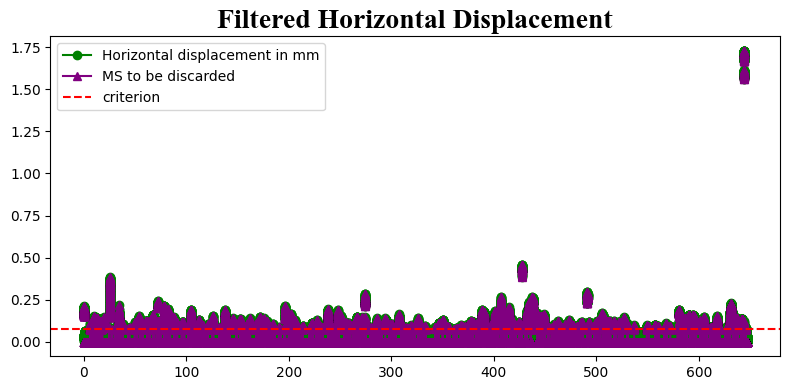

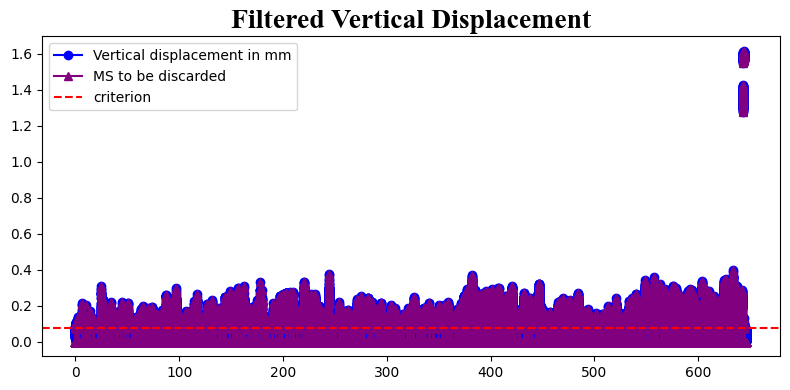

In [97]:
plot_h_v_disp(h_dis_ft, v_dis_ft, discarded_x_mask, 
              discarded_y_mask, criteria_ratio=criteria_ratio)



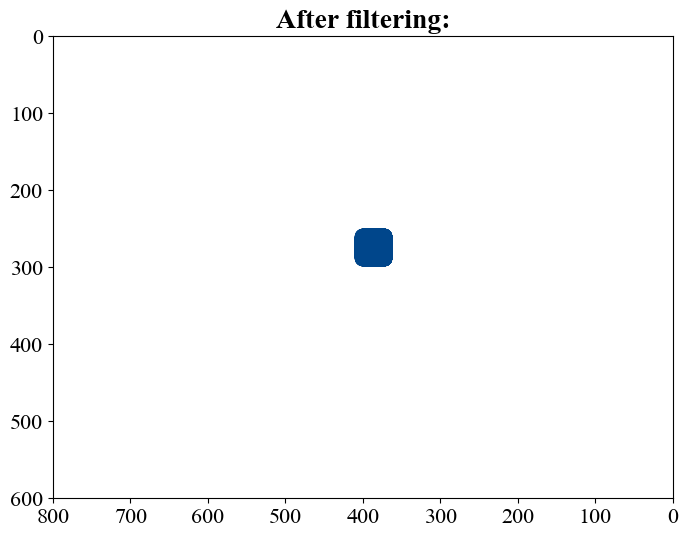

In [98]:
coor_data_ft_clean, Preserve_mask, Discard_mask = filter_XY_with_mask(coor_data_LIBRE_ft, discarded_x_mask, 
                                                                        discarded_y_mask, seq_name=None)


====
x_coordinate --- statistics
Mean distance: 387.18
Standard deviation: 12.08
Median distance: 386.60
Minimum distance: 301.20
Maximum distance: 711.50
Number of NaN values: 69157

====
y_coordinate --- statistics
Mean distance: 273.26
Standard deviation: 13.16
Median distance: 273.60
Minimum distance: 197.90
Maximum distance: 583.10
Number of NaN values: 69157


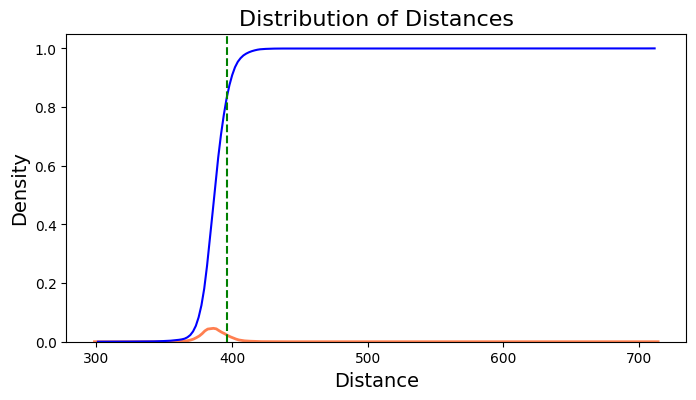

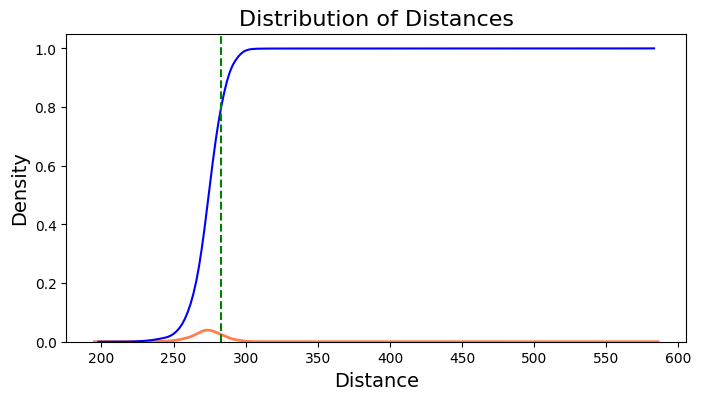

In [99]:
print('\n====\nx_coordinate --- statistics')
cal_statistics(coor_data_LIBRE_ft['x_coordinate'])
print('\n====\ny_coordinate --- statistics')
cal_statistics(coor_data_LIBRE_ft['y_coordinate'])
threshold_value_x = plt_distribution(coor_data_LIBRE_ft['x_coordinate'], threshold=0.8)
threshold_value_y = plt_distribution(coor_data_LIBRE_ft['y_coordinate'], threshold=0.8)

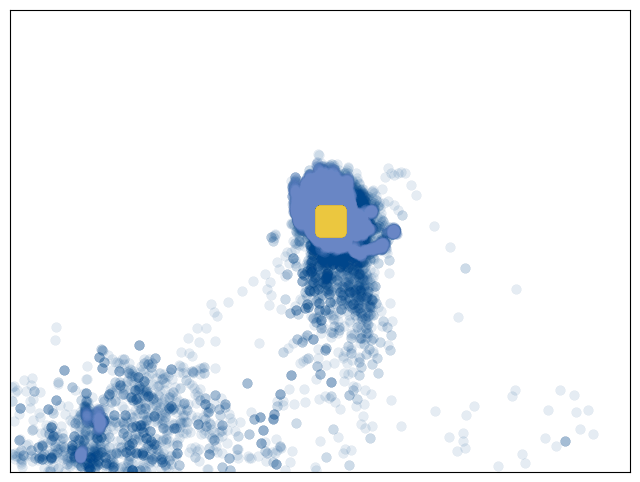

In [100]:

# Visualization of filtered coor data LIBRE

visualization_func(fig_title='Before vs After (filtering)', 
                   coor_data_raw = coor_data_LIBRE_raw, coor_data=coor_data_LIBRE_ft, coor_data_clean=coor_data_ft_clean)

output_figs_dir = Path("./output_figs/"+subject_idx)
output_figs_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(Path(output_figs_dir/"2_0_mreye_et_filtering.pdf"), dpi=300, bbox_inches='tight')

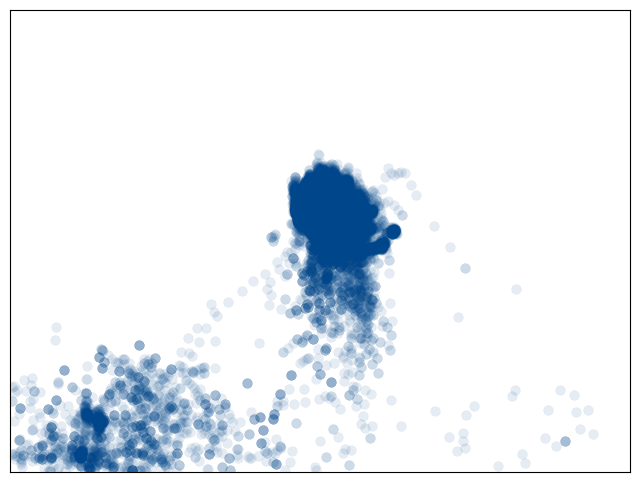

In [101]:
visualization_func(fig_title='Before vs After (filtering)', 
                   coor_data_raw = coor_data_LIBRE_raw, coor_data=0, coor_data_clean=0)

plt.savefig(Path(output_figs_dir/"2_0_mreye_et_raw.pdf"), dpi=300, bbox_inches='tight')

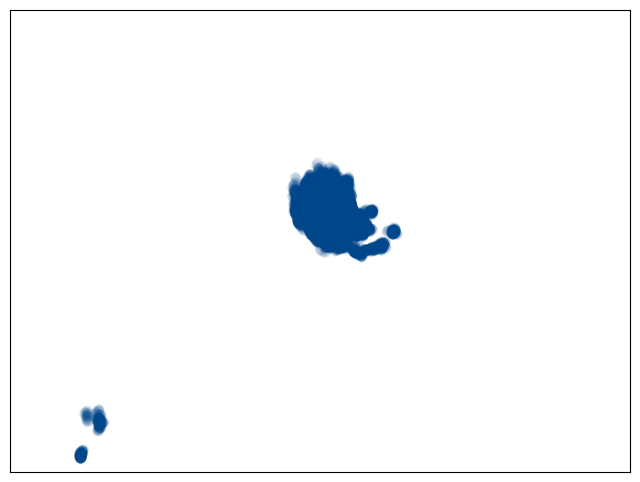

In [102]:
visualization_func(fig_title='Before vs After (filtering)', 
                   coor_data_raw = coor_data_LIBRE_ft, coor_data=0, coor_data_clean=0)

plt.savefig(Path(output_figs_dir/"2_0_mreye_et_nomo.pdf"), dpi=300, bbox_inches='tight')

In [106]:
count_true = np.sum(Preserve_mask)
print(f'Preserved #ET samples: {count_true}')
print(f'Size of mask before concatenation: {len(Preserve_mask)}')
preffix_mask = np.zeros(offset)
print(f'Concatenating prefix offset {offset}')
# Concatenate the two arrays
Preserve_mask_cat = np.concatenate((preffix_mask, Preserve_mask))
print(f'Size of mask after concatenation: {len(Preserve_mask_cat)}')
print(f'twix_duration: {twix_duration}')
assert len(Preserve_mask_cat) == np.round(twix_duration)
# Save the Preserve_mask
import os
import scipy.io as sio
save_mask = True

if save_mask:
    mask_name = f'subject_{subject_idx}_mask_clean_{criteria_ratio}.mat'

    SAVE_PATH = './masks/'+subject_idx+'/'

    # Create the folder if it doesn't exist
    os.makedirs(SAVE_PATH, exist_ok=True)
    mask_file = SAVE_PATH + mask_name

    # Save array to a .mat file
    sio.savemat(mask_file, {'array': Preserve_mask_cat})
    print(f'The mask file has been saved here: {mask_file}')

Preserved #ET samples: 405733
Size of mask before concatenation: 646612
Concatenating prefix offset 6
Size of mask after concatenation: 646618
twix_duration: 646617.5
The mask file has been saved here: ./masks/MID00137/subject_MID00137_mask_clean_0.15.mat


In [107]:
save_Discard_mask = False

if save_Discard_mask:
    Discard_mask = ~Preserve_mask
    count_true = np.sum(Discard_mask)
    print(count_true)
    preffix_mask = np.ones(offset)
    # Concatenate the two arrays
    Discard_mask = np.concatenate((preffix_mask, Discard_mask))
    print(f'Size of mask after concatenation: {len(Discard_mask)}')
    # Save the Preserve_mask
    import os
    import scipy.io as sio
    
    mask_name = f'subject_{subject_idx}_discard_mask_{criteria_ratio}.mat'
    
    SAVE_PATH = './masks/'+subject_idx+'/'

    # Create the folder if it doesn't exist
    os.makedirs(SAVE_PATH, exist_ok=True)
    mask_file = SAVE_PATH + mask_name

    # Save array to a .mat file
    sio.savemat(mask_file, {'array': Discard_mask})
    print(f'The mask file has been saved here: {mask_file}')

Organize the mask files to the HPC

In [108]:
import subprocess
from pathlib import Path

src = Path("./masks/"+subject_idx)
dst = Path(
    "/Volumes/FS_PROJETS/MatTechLab/yiwei.jia/"
    "recon_results/"+ RECON_FOLDER_DATE + "/"+ subject_idx + "_recon/T1_LIBRE_Binning/et_masks"
)

# Ensure destination exists
dst.mkdir(parents=True, exist_ok=True)

# rsync command
cmd = [
    "rsync",
    "-av",          # archive + verbose
    f"{src}/",      # trailing slash is IMPORTANT
    f"{dst}/"
]

print("Running:", " ".join(cmd))
subprocess.run(cmd, check=True)

dst_local = Path(
    "/Users/cag/Documents/Dataset/"
    "recon_results/"+ RECON_FOLDER_DATE + "/"+ subject_idx + "_recon/T1_LIBRE_Binning/et_masks"
)

# Ensure destination exists
dst_local.mkdir(parents=True, exist_ok=True)

# rsync command
cmd = [
    "rsync",
    "-av",          # archive + verbose
    f"{src}/",      # trailing slash is IMPORTANT
    f"{dst_local}/"
]
print("Running:", " ".join(cmd))
subprocess.run(cmd, check=True)

Running: rsync -av masks/MID00137/ /Volumes/FS_PROJETS/MatTechLab/yiwei.jia/recon_results/26021801/MID00137_recon/T1_LIBRE_Binning/et_masks/
building file list ... done
./
subject_MID00137_mask_clean_0.15.mat

sent 5174002 bytes  received 66 bytes  3449378.67 bytes/sec
total size is 20692544  speedup is 4.00
Running: rsync -av masks/MID00137/ /Users/cag/Documents/Dataset/recon_results/26021801/MID00137_recon/T1_LIBRE_Binning/et_masks/
building file list ... done
subject_MID00137_mask_clean_0.15.mat

sent 5173978 bytes  received 42 bytes  10348040.00 bytes/sec
total size is 20692544  speedup is 4.00


CompletedProcess(args=['rsync', '-av', 'masks/MID00137/', '/Users/cag/Documents/Dataset/recon_results/26021801/MID00137_recon/T1_LIBRE_Binning/et_masks/'], returncode=0)